###import dataset and show

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import zipfile
import pandas as pd

zip_path = "/content/drive/MyDrive/StudentsPerformanceinExams_dataset/archive (1).zip"
extract_path = "/content/drive/MyDrive/StudentsPerformanceinExams_dataset/extracted_data"

print("ไฟล์ zip มีอยู่หรือไม่:", os.path.exists(zip_path))

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("แตกไฟล์เรียบร้อยแล้ว")

for root, dirs, files in os.walk(extract_path):
    print("Folder:", root)
    for file in files:
        print("  -", file)

csv_path = os.path.join(extract_path, "StudentsPerformance.csv")
print("CSV path:", csv_path)
print("CSV exists:", os.path.exists(csv_path))

df = pd.read_csv(csv_path)

print("\nShape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nInfo:")
df.info()

print("\nFirst 5 rows:")
display(df.head())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ไฟล์ zip มีอยู่หรือไม่: True
แตกไฟล์เรียบร้อยแล้ว
Folder: /content/drive/MyDrive/StudentsPerformanceinExams_dataset/extracted_data
  - StudentsPerformance.csv
CSV path: /content/drive/MyDrive/StudentsPerformanceinExams_dataset/extracted_data/StudentsPerformance.csv
CSV exists: True

Shape: (1000, 8)

Columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch         

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75



Missing values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Duplicate rows: 0


In [3]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [4]:
print("Mean math score    :", df["math score"].mean())
print("Mean reading score :", df["reading score"].mean())
print("Mean writing score :", df["writing score"].mean())

Mean math score    : 66.089
Mean reading score : 69.169
Mean writing score : 68.054


###import library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

###Prepare zone & EDA

In [5]:
df["average_score"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
) / 3

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


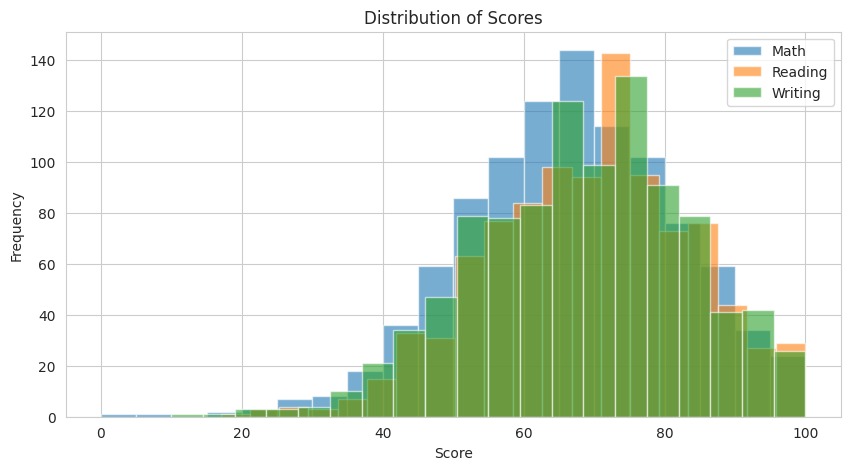

In [6]:
#for watch range of data
plt.figure(figsize=(10, 5))
plt.hist(df["math score"], bins=20, alpha=0.6, label="Math")
plt.hist(df["reading score"], bins=20, alpha=0.6, label="Reading")
plt.hist(df["writing score"], bins=20, alpha=0.6, label="Writing")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.title("Distribution of Scores")
plt.legend()
plt.show()

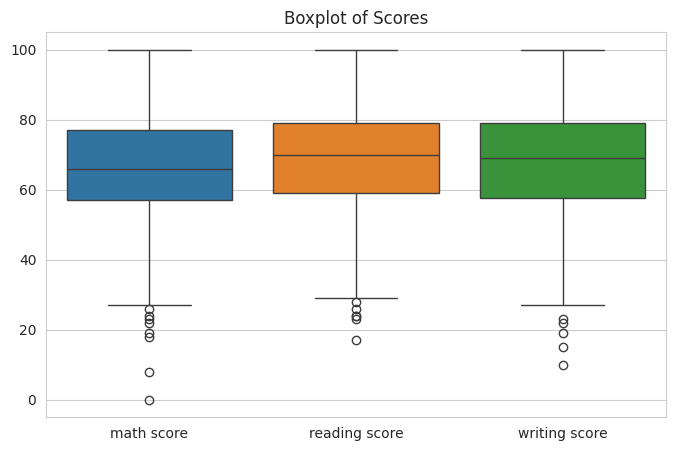

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[["math score", "reading score", "writing score"]])
plt.title("Boxplot of Scores")
plt.show()

In [8]:
#watching gender counts
df["gender"].value_counts()

,count
gender,
female,518
male,482


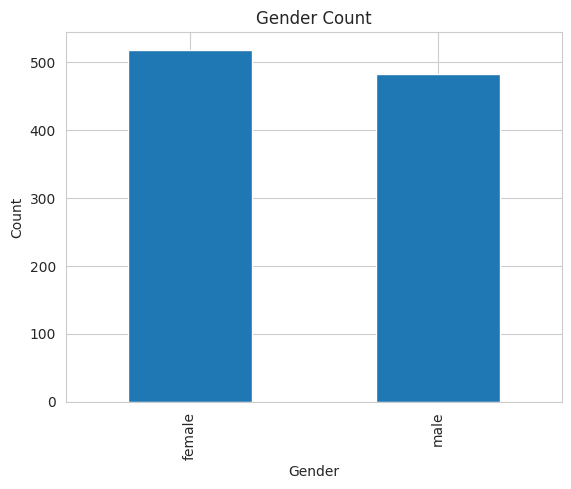

In [9]:
df["gender"].value_counts().plot(kind="bar")
plt.title("Gender Count")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

In [10]:
#test preparation course
df.groupby("test preparation course")[["math score", "reading score", "writing score"]].mean()

,math score,reading score,writing score
test preparation course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


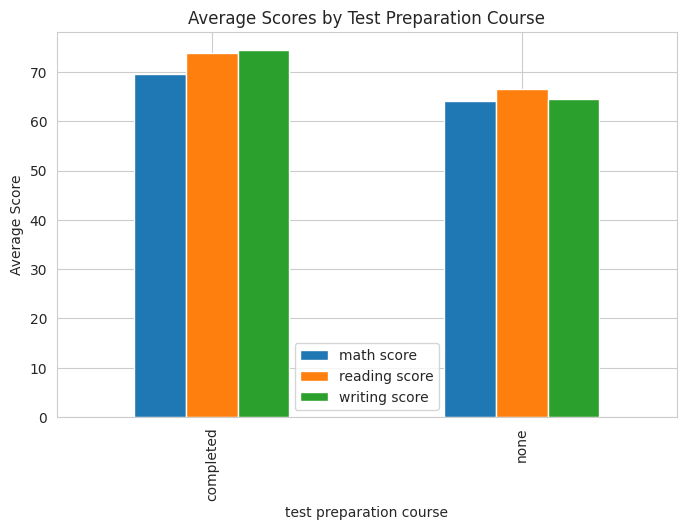

In [11]:
df.groupby("test preparation course")[["math score", "reading score", "writing score"]].mean().plot(kind="bar", figsize=(8,5))
plt.title("Average Scores by Test Preparation Course")
plt.ylabel("Average Score")
plt.show()

In [12]:
df.groupby("lunch")[["math score", "reading score", "writing score"]].mean()

,math score,reading score,writing score
lunch,,,
free/reduced,58.921127,64.653521,63.022535
standard,70.034109,71.654264,70.823256


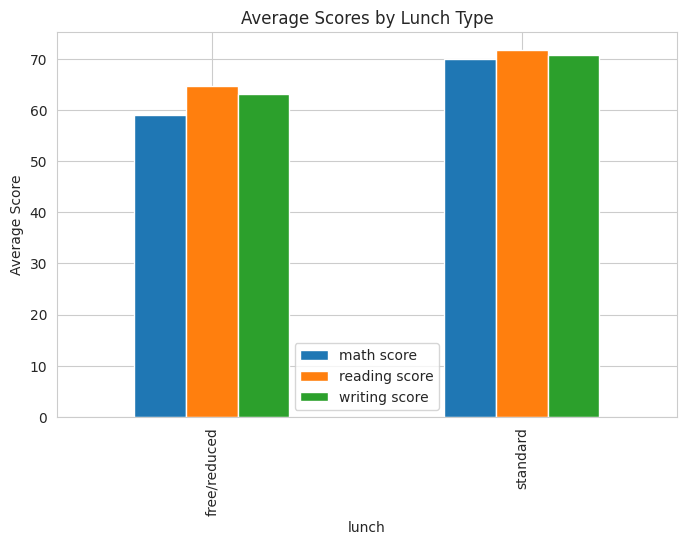

In [13]:
df.groupby("lunch")[["math score", "reading score", "writing score"]].mean().plot(kind="bar", figsize=(8,5))
plt.title("Average Scores by Lunch Type")
plt.ylabel("Average Score")
plt.show()

In [14]:
df.groupby("parental level of education")[["math score", "reading score", "writing score"]].mean().sort_values(by="math score")

,math score,reading score,writing score
parental level of education,,,
high school,62.137755,64.704082,62.448980
some high school,63.497207,66.938547,64.888268
some college,67.128319,69.460177,68.840708
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
master's degree,69.745763,75.372881,75.677966


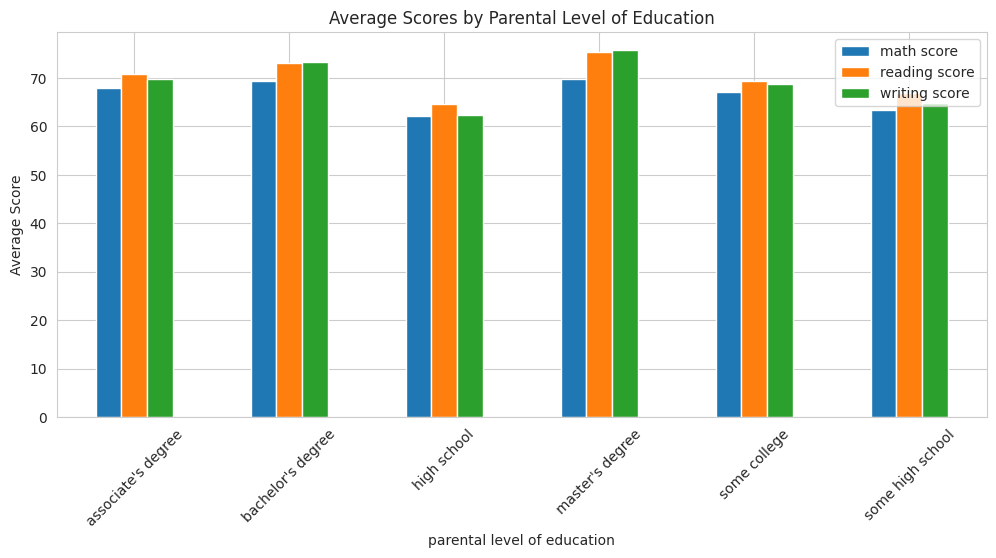

In [15]:
df.groupby("parental level of education")[["math score", "reading score", "writing score"]].mean().plot(kind="bar", figsize=(12,5))
plt.title("Average Scores by Parental Level of Education")
plt.ylabel("Average Score")
plt.xticks(rotation=45)
plt.show()

In [16]:
corr = df[["math score", "reading score", "writing score", "average_score"]].corr()
corr

,math score,reading score,writing score,average_score
math score,1.000000,0.817580,0.802642,0.918746
reading score,0.817580,1.000000,0.954598,0.970331
writing score,0.802642,0.954598,1.000000,0.965667
average_score,0.918746,0.970331,0.965667,1.000000


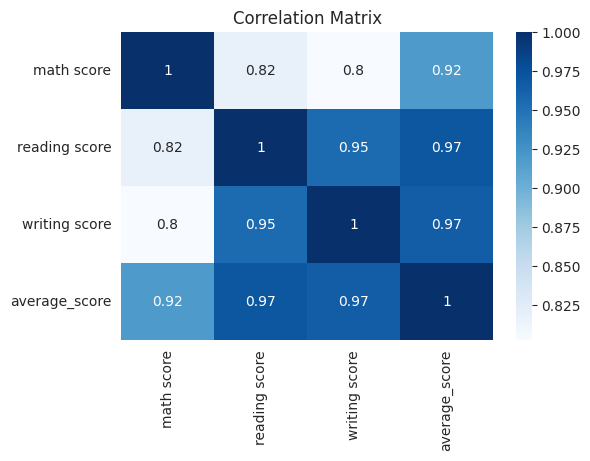

In [17]:
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

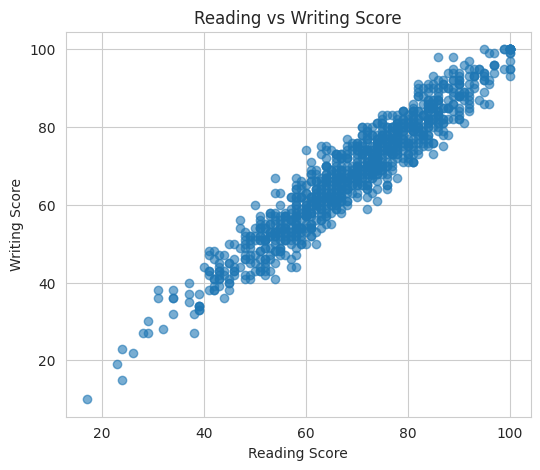

In [18]:
plt.figure(figsize=(6,5))
plt.scatter(df["reading score"], df["writing score"], alpha=0.6)
plt.xlabel("Reading Score")
plt.ylabel("Writing Score")
plt.title("Reading vs Writing Score")
plt.show()

###Regression model

<details>
<summary><b>Step 1: เป้าหมายของงาน Regression</b></summary>

งานนี้เราต้องการทำนายค่า average_score ของนักเรียน
โดยใช้ข้อมูลพื้นฐาน เช่น gender, race/ethnicity,
parental level of education, lunch, test preparation course

โมเดลที่ใช้:
- Random Forest Regressor

เหตุผลที่เลือก:
- รองรับความสัมพันธ์แบบ non-linear ได้ดี
- ใช้กับข้อมูลตารางได้ดี
- มักแม่นกว่า Linear Regression เมื่อ pattern ซับซ้อน
- ไม่ต้องกังวลเรื่อง scaling มากเท่า KNN/SVM

</details>

In [19]:
# สร้าง average_score เป็นตัวแปรเป้าหมาย (target)
df["average_score"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
) / 3

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


<details>
<summary><b>Step 2: เลือก feature และ target</b></summary>

Feature (X) คือข้อมูลที่ใช้ทำนาย
Target (y) คือค่าที่เราต้องการให้โมเดลทำนาย

ในงานนี้:
- X = ข้อมูลพื้นฐานของนักเรียน
- y = average_score

หมายเหตุ:
เราจะยังไม่ใช้ math score, reading score, writing score เป็น feature
เพราะ average_score ถูกคำนวณมาจาก 3 ตัวนี้โดยตรง
ถ้าเอามาใช้ทำนาย จะเหมือนแอบเฉลยคำตอบให้โมเดล

</details>

In [20]:
# เลือกเฉพาะข้อมูลพื้นฐานเป็น feature
feature_cols = [
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course"
]

X = df[feature_cols]
y = df["average_score"]

print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())
display(y.head())

X shape: (1000, 5)
y shape: (1000,)


,gender,race/ethnicity,parental level of education,lunch,test preparation course
0,female,group B,bachelor's degree,standard,none
1,female,group C,some college,standard,completed
2,female,group B,master's degree,standard,none
3,male,group A,associate's degree,free/reduced,none
4,male,group C,some college,standard,none


,average_score
0,72.666667
1,82.333333
2,92.666667
3,49.333333
4,76.333333


<details>
<summary><b>Step 3: แปลงข้อมูล categorical ให้เป็นตัวเลข</b></summary>

Machine Learning model ส่วนใหญ่รับข้อมูลเป็นตัวเลข
แต่ feature ของเราหลายตัวเป็นข้อความ เช่น male/female, standard/free-reduced

ดังนั้นเราต้องแปลงข้อความให้เป็นตัวเลขก่อน
วิธีที่ใช้คือ One-Hot Encoding

ตัวอย่าง:
gender:
- male -> [1, 0]
- female -> [0, 1]

</details>

In [21]:
X_encoded = pd.get_dummies(X, drop_first=False)

print("Shape หลัง encoding:", X_encoded.shape)
display(X_encoded.head())

Shape หลัง encoding: (1000, 17)


,gender_female,gender_male,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_associate's degree,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_free/reduced,lunch_standard,test preparation course_completed,test preparation course_none
0,True,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,True
1,True,False,False,False,True,False,False,False,False,False,False,True,False,False,True,True,False
2,True,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,True
3,False,True,True,False,False,False,False,True,False,False,False,False,False,True,False,False,True
4,False,True,False,False,True,False,False,False,False,False,False,True,False,False,True,False,True


<details>
<summary><b>Step 4: แบ่งข้อมูล Train/Test</b></summary>

เราไม่ควรใช้ข้อมูลทั้งหมดฝึกโมเดลแล้ววัดผลบนข้อมูลชุดเดิม
เพราะจะไม่รู้ว่าโมเดลเก่งจริง หรือแค่จำข้อมูลได้

ดังนั้นเราจะแบ่งเป็น:
- Train set = ใช้ฝึกโมเดล
- Test set = ใช้ทดสอบโมเดล

สัดส่วนที่ใช้:
- Train 80%
- Test 20%

</details>

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (800, 17)
X_test shape : (200, 17)
y_train shape: (800,)
y_test shape : (200,)


<details>
<summary><b>Step 5: สร้างและฝึก Random Forest Regressor</b></summary>

Random Forest คือการรวมต้นไม้ตัดสินใจหลายต้นเข้าด้วยกัน
แล้วให้ผลลัพธ์เฉลี่ยกัน

ข้อดี:
- จับความสัมพันธ์ซับซ้อนได้
- ทนต่อ noise ได้พอสมควร
- ใช้กับ tabular data ได้ดี

ค่าที่ตั้งเบื้องต้น:
- n_estimators = จำนวนต้นไม้
- max_depth = ความลึกสูงสุดของต้นไม้ (ถ้าไม่กำหนด ต้นไม้อาจลึกมาก)

</details>

In [23]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_reg.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

<details>
<summary><b>Step 6: ทำนายผลบน Test Set</b></summary>

หลังฝึกเสร็จ เราจะให้โมเดลทำนาย average_score
จากข้อมูลที่มันไม่เคยเห็นมาก่อน

</details>

In [24]:
y_pred = rf_reg.predict(X_test)

print("ตัวอย่างค่าจริง 10 ค่าแรก:")
print(y_test.iloc[:10].values)

print("\nตัวอย่างค่าที่โมเดลทำนาย 10 ค่าแรก:")
print(y_pred[:10])

ตัวอย่างค่าจริง 10 ค่าแรก:
[87.         64.         75.         74.66666667 81.66666667 78.
 67.33333333 59.         77.33333333 48.66666667]

ตัวอย่างค่าที่โมเดลทำนาย 10 ค่าแรก:
[66.87401876 70.35750794 62.37060317 56.97927579 79.91314947 60.04758929
 69.12714087 60.75215873 59.99797109 70.63957083]


<details>
<summary><b>Step 7: ประเมินผลโมเดล Regression</b></summary>

Metric ที่นิยมใช้:
- MAE  = ค่าความผิดพลาดเฉลี่ยแบบค่าสัมบูรณ์
- MSE  = ค่าความผิดพลาดกำลังสองเฉลี่ย
- RMSE = รากที่สองของ MSE
- R²   = โมเดลอธิบายความแปรปรวนได้มากแค่ไหน

การตีความ:
- MAE / RMSE ยิ่งต่ำยิ่งดี
- R² ยิ่งใกล้ 1 ยิ่งดี

</details>

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 11.519420287124412
MSE : 220.48102856431268
RMSE: 14.848603589708787
R²  : -0.02852339332911824


<details>
<summary><b>Step 8: เปรียบเทียบค่าจริงกับค่าที่ทำนาย</b></summary>

เราจะสร้างตารางเปรียบเทียบระหว่าง:
- Actual = ค่าจริง
- Predicted = ค่าที่โมเดลทำนาย
- Error = ความคลาดเคลื่อน

</details>

In [26]:
results_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
})

results_df["Error"] = results_df["Actual"] - results_df["Predicted"]
results_df["Absolute Error"] = results_df["Error"].abs()

display(results_df.head(20))

,Actual,Predicted,Error,Absolute Error
0,87.000000,66.874019,20.125981,20.125981
1,64.000000,70.357508,-6.357508,6.357508
2,75.000000,62.370603,12.629397,12.629397
3,74.666667,56.979276,17.687391,17.687391
4,81.666667,79.913149,1.753517,1.753517
5,78.000000,60.047589,17.952411,17.952411
6,67.333333,69.127141,-1.793808,1.793808
7,59.000000,60.752159,-1.752159,1.752159
8,77.333333,59.997971,17.335362,17.335362
9,48.666667,70.639571,-21.972904,21.972904


<details>
<summary><b>Step 9: ดูความสำคัญของ Feature</b></summary>

Random Forest สามารถบอกได้ว่า feature ไหนสำคัญต่อการทำนายมากกว่า

สิ่งนี้ช่วยตอบคำถามเชิงตีความ เช่น:
- test preparation course สำคัญไหม
- lunch สำคัญไหม
- gender สำคัญไหม

</details>

In [27]:
importances = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": rf_reg.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(importances.head(15))

,Feature,Importance
14,lunch_standard,0.101597
15,test preparation course_completed,0.089084
13,lunch_free/reduced,0.077998
16,test preparation course_none,0.064333
9,parental level of education_high school,0.062823
3,race/ethnicity_group B,0.059352
0,gender_female,0.057636
6,race/ethnicity_group E,0.057377
8,parental level of education_bachelor's degree,0.056283
1,gender_male,0.053336


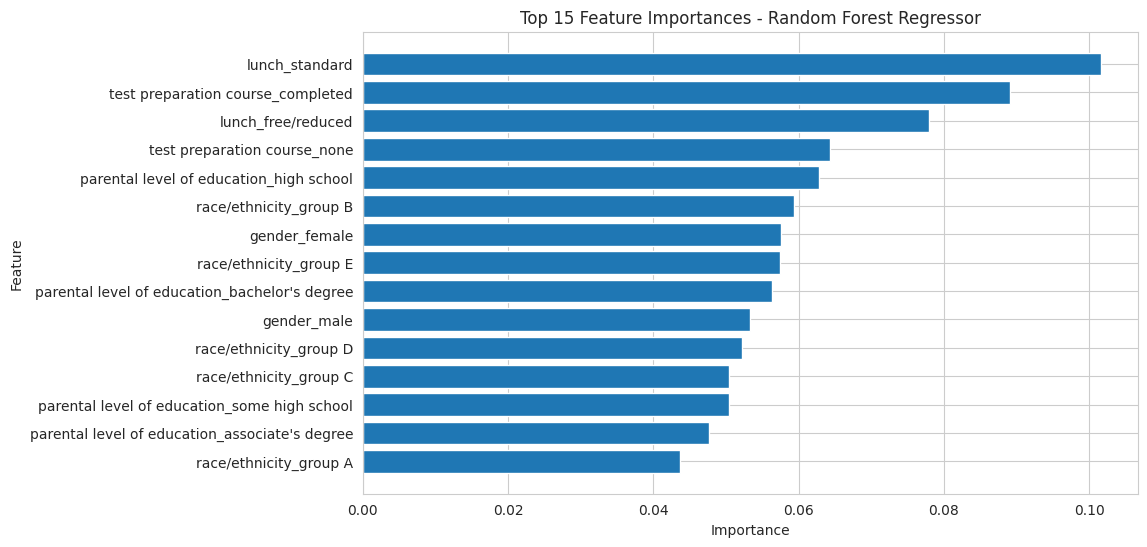

In [28]:
plt.figure(figsize=(10, 6))
plt.barh(importances["Feature"].head(15)[::-1], importances["Importance"].head(15)[::-1])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Random Forest Regressor")
plt.show()

<details>
<summary><b>Step 10: สรุปผลเบื้องต้น</b></summary>

สิ่งที่ควรสรุปหลังรัน:
1. โมเดล Random Forest Regressor ทำนาย average_score ได้ดีหรือไม่
2. ค่าความผิดพลาดเฉลี่ยอยู่ประมาณกี่คะแนน
3. Feature ไหนมีผลกับการทำนายมากที่สุด
4. โมเดลนี้เหมาะใช้เป็น baseline regression ของ dataset นี้หรือไม่

</details>

MAE : 11.519420287124412
MSE : 220.48102856431268
RMSE: 14.848603589708787
R²  : -0.02852339332911824


,Actual,Predicted,Error,Absolute Error
0,87.000000,66.874019,20.125981,20.125981
1,64.000000,70.357508,-6.357508,6.357508
2,75.000000,62.370603,12.629397,12.629397
3,74.666667,56.979276,17.687391,17.687391
4,81.666667,79.913149,1.753517,1.753517
5,78.000000,60.047589,17.952411,17.952411
6,67.333333,69.127141,-1.793808,1.793808
7,59.000000,60.752159,-1.752159,1.752159
8,77.333333,59.997971,17.335362,17.335362
9,48.666667,70.639571,-21.972904,21.972904


,Feature,Importance
14,lunch_standard,0.101597
15,test preparation course_completed,0.089084
13,lunch_free/reduced,0.077998
16,test preparation course_none,0.064333
9,parental level of education_high school,0.062823
3,race/ethnicity_group B,0.059352
0,gender_female,0.057636
6,race/ethnicity_group E,0.057377
8,parental level of education_bachelor's degree,0.056283
1,gender_male,0.053336


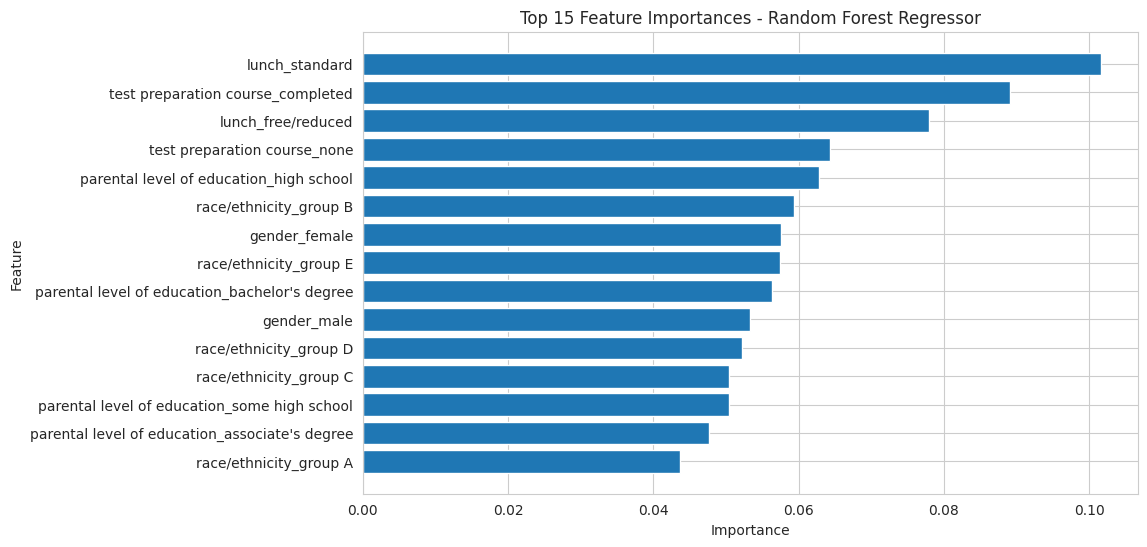

In [29]:
# Step A1: create target
df["average_score"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
) / 3

# Step A2: select features and target
feature_cols = [
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course"
]

X = df[feature_cols]
y = df["average_score"]

# Step A3: one-hot encoding
X_encoded = pd.get_dummies(X, drop_first=False)

# Step A4: split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

# Step A5: train Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_reg.fit(X_train, y_train)

# Step A6: prediction
y_pred = rf_reg.predict(X_test)

# Step A7: evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

# Step A8: compare actual vs predicted
results_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
})
results_df["Error"] = results_df["Actual"] - results_df["Predicted"]
results_df["Absolute Error"] = results_df["Error"].abs()

display(results_df.head(20))

# Step A9: feature importance
importances = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": rf_reg.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(importances.head(15))

# Step A10: plot feature importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(importances["Feature"].head(15)[::-1], importances["Importance"].head(15)[::-1])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Random Forest Regressor")
plt.show()

<details>
<summary><b>Version edit for performance</b></summary>


1.   n_estimators=500

เพิ่มจำนวนต้นไม้
ช่วยลดความผันผวนของโมเดล เพราะค่าเฉลี่ยจากหลายต้นไม้เสถียรกว่า

2.   max_depth=8

จำกัดความลึกของต้นไม้
ช่วยกัน overfitting

3.  min_samples_split=10, min_samples_leaf=5

บังคับให้แต่ละ leaf ไม่เล็กเกินไป
ทำให้ prediction ไม่แกว่งตามจุดข้อมูล少เกินไป

4.  max_features="sqrt"

สุ่มใช้ feature บางส่วนต่อการ split
ช่วยให้ต้นไม้หลากหลายขึ้น

</details>

In [30]:
import pandas as pd
import numpy as np

# ---------- 1) เตรียม target ----------
df["average_score"] = (
    df["math score"] + df["reading score"] + df["writing score"]
) / 3

# ---------- 2) feature engineering ----------
edu_map = {
    "some high school": 0,
    "high school": 1,
    "some college": 2,
    "associate's degree": 3,
    "bachelor's degree": 4,
    "master's degree": 5
}

df["parent_edu_rank"] = df["parental level of education"].map(edu_map)
df["prep_completed"] = (df["test preparation course"] == "completed").astype(int)
df["standard_lunch"] = (df["lunch"] == "standard").astype(int)

# interaction features
df["prep_x_lunch"] = df["prep_completed"] * df["standard_lunch"]
df["prep_x_parentedu"] = df["prep_completed"] * df["parent_edu_rank"]

# ---------- 3) เลือก features ----------
feature_cols = [
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course",
    "parent_edu_rank",
    "prep_completed",
    "standard_lunch",
    "prep_x_lunch",
    "prep_x_parentedu"
]

X = df[feature_cols]
y = df["average_score"]

# one-hot encode
X_encoded = pd.get_dummies(X, drop_first=True)

# ---------- 4) split data ----------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

# ---------- 5) model ----------
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(
    n_estimators=500,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_reg.fit(X_train, y_train)

# ---------- 6) predict ----------
y_pred = rf_reg.predict(X_test)

# ---------- 7) evaluate ----------
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 10.700511564807561
MSE : 188.67166782252497
RMSE: 13.735780568374153
R²  : 0.11986430180643082


In [31]:
# เปรียบเทียบค่าจริง (y_test) กับค่าที่โมเดลทำนาย (y_pred)
compare_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

compare_df["Error"] = compare_df["Actual"] - compare_df["Predicted"]
compare_df["Absolute Error"] = compare_df["Error"].abs()

display(compare_df.head(20))

,Actual,Predicted,Error,Absolute Error
0,87.000000,68.795138,18.204862,18.204862
1,64.000000,69.091364,-5.091364,5.091364
2,75.000000,69.223385,5.776615,5.776615
3,74.666667,57.566565,17.100101,17.100101
4,81.666667,78.046812,3.619854,3.619854
5,78.000000,59.507251,18.492749,18.492749
6,67.333333,70.406722,-3.073389,3.073389
7,59.000000,70.897352,-11.897352,11.897352
8,77.333333,59.531293,17.802040,17.802040
9,48.666667,68.751658,-20.084991,20.084991


In [32]:
# เรียงจากค่าที่พลาดมากที่สุด
compare_df_sorted = compare_df.sort_values(by="Absolute Error", ascending=False)
display(compare_df_sorted.head(20))

,Actual,Predicted,Error,Absolute Error
39,9.000000,56.535158,-47.535158,47.535158
11,26.000000,71.037795,-45.037795,45.037795
47,29.333333,69.668942,-40.335609,40.335609
94,29.666667,69.367536,-39.700870,39.700870
89,23.333333,59.044566,-35.711233,35.711233
110,39.000000,67.619023,-28.619023,28.619023
111,80.000000,51.430051,28.569949,28.569949
175,31.000000,58.868371,-27.868371,27.868371
60,43.333333,70.547645,-27.214311,27.214311
167,88.666667,61.764484,26.902182,26.902182


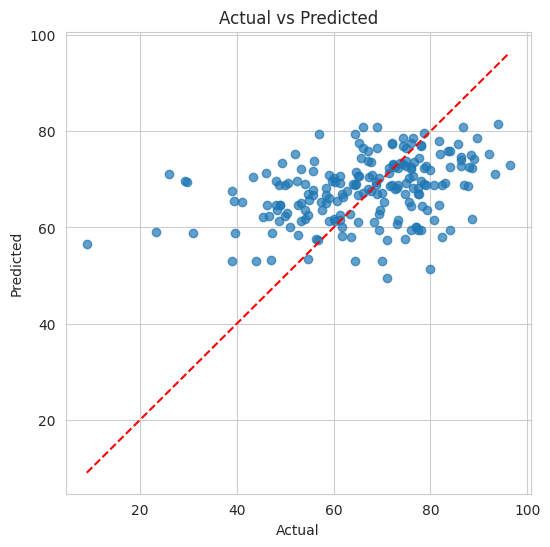

In [33]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

# เส้นอุดมคติ y = x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.show()